In [1]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import wandb
import h5py

import sys
sys.path.append('../../../src/benchmark/')
sys.path.append('../../../src/utils/')
sys.path.append('../../../src/preprocessing/')

from build_model import resnet50_
from train_functions import train_epochs
from utils import split_train_valid, list_to_dict, viz_dataloader, hdf5_dataset
from viz import show_images

c:\Users\yig319\Anaconda3\envs\symmetry\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
with h5py.File('../../../datasets/imagenet_v4_rot_10m_100k_subset-size-RRR.h5') as h5:
    print(h5.keys())    

<KeysViewHDF5 ['atom', 'imagenet', 'noise']>


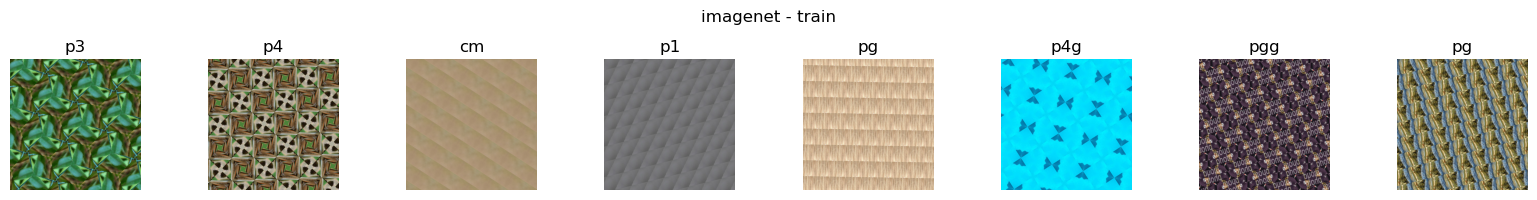

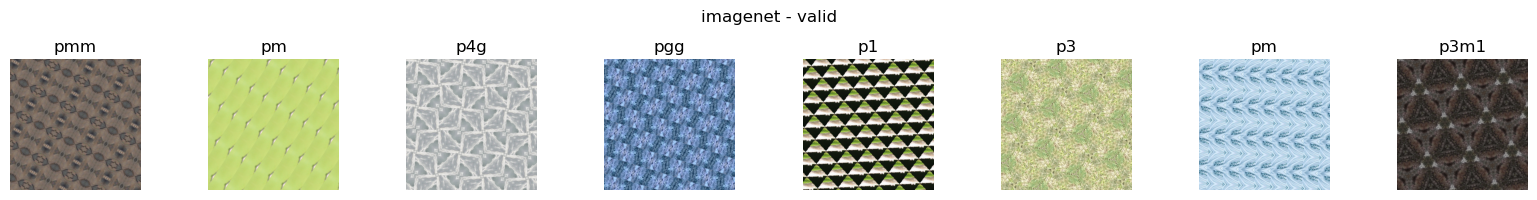

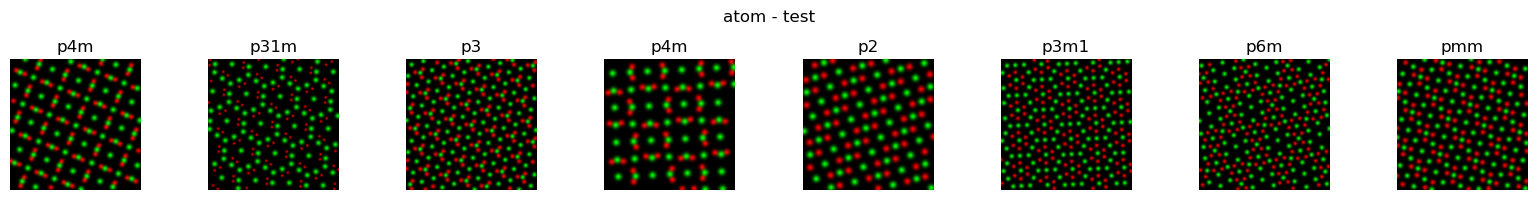

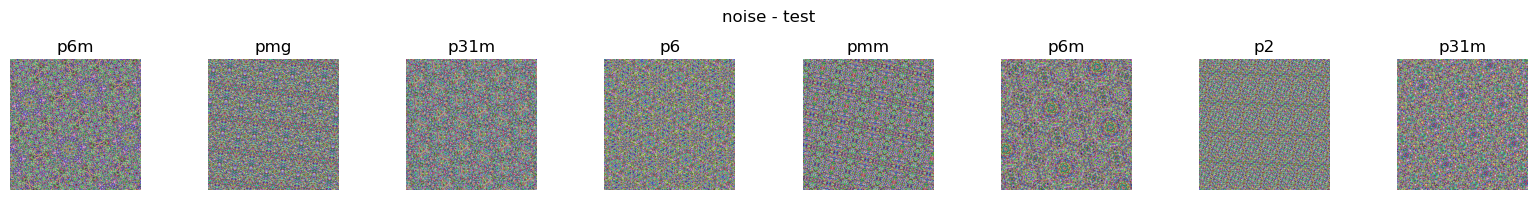

In [2]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

bs = 64
# imagenet
imagenet_ds = hdf5_dataset('../../../datasets/imagenet_v4_rot_10m_100k_subset-size-RRR.h5', folder='imagenet', transform=transforms.ToTensor())
train_ds, valid_ds = split_train_valid(imagenet_ds, 0.8)
train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True, num_workers=2)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train')
valid_dl = DataLoader(valid_ds, batch_size=bs, shuffle=False, num_workers=2)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid')

# atom
test_atom_ds = hdf5_dataset('../../../datasets/imagenet_v4_rot_10m_100k_subset-size-RRR.h5', folder='atom', transform=transforms.ToTensor())
test_atom_dl = DataLoader(test_atom_ds, batch_size=bs, shuffle=False, num_workers=2)
viz_dataloader(test_atom_dl, label_converter=label_converter, title='atom - test')

# noise
test_noise_ds = hdf5_dataset('../../../datasets/imagenet_v4_rot_10m_100k_subset-size-RRR.h5', folder='noise', transform=transforms.ToTensor())
test_noise_dl = DataLoader(test_noise_ds, batch_size=bs, shuffle=False, num_workers=2)
viz_dataloader(test_noise_dl, label_converter=label_converter, title='noise - test')

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.cuda.amp import GradScaler, autocast

class SplineActivation(nn.Module):
    def __init__(self, num_params=10):
        super(SplineActivation, self).__init__()
        self.spline_params = nn.Parameter(torch.randn(num_params))
    
    def forward(self, x):
        x_powers = torch.stack([x**i for i in range(len(self.spline_params))], dim=-1)
        return torch.sum(self.spline_params * x_powers, dim=-1)

class KANLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super(KANLayer, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.activations = nn.ModuleList([SplineActivation() for _ in range(in_features * out_features)])
    
    def forward(self, x):
        batch_size = x.size(0)
        x = x.view(batch_size, -1, self.in_features)
        out = []
        for i in range(self.out_features):
            weighted_sum = torch.stack([self.activations[i * self.in_features + j](x[:, :, j]) for j in range(self.in_features)], dim=-1)
            out.append(torch.sum(weighted_sum, dim=-1))
        return torch.stack(out, dim=-1).squeeze()

def resnet50_KAN(in_channels, n_classes, dropout=0.5, weights=None):
    model = models.resnet50(weights=weights)
    model.conv1 = nn.Conv2d(in_channels, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    
    # Ensure the output from ResNet matches the input for KANLayer
    model.fc = nn.Sequential(
        # nn.BatchNorm1d(2048),
        # nn.Dropout(p=dropout, inplace=False),
        # KANLayer(2048, 512),  # Adjust input and output dimensions accordingly
        # nn.ReLU(inplace=True),
        
        # nn.BatchNorm1d(512),
        # nn.Dropout(p=dropout, inplace=False),
        # KANLayer(512, 64),  # Further process the features
        # nn.ReLU(inplace=True),
        
        nn.BatchNorm1d(2048),
        nn.Dropout(p=dropout, inplace=False),
        KANLayer(2048, n_classes)  # Final layer to match number of classes
    )
    return model

# Parameters
model = resnet50_KAN(3, 17)  # Define model
device = torch.device('cuda:0')  # Use GPU

model = model.to(device)
outputs = model(torch.randn(2, 3, 256, 256).to(device))
print(outputs.shape)  # Should print (2, 17)

torch.Size([2, 17])


In [21]:
device = torch.device('cuda:0')

model = model.to(device)
outputs = model(torch.randn(2, 3, 256, 256).to(device))
print(outputs.shape)

torch.Size([2, 17])


In [22]:
inputs, labels = next(iter(train_dl))

In [23]:
outputs = model(inputs.to(device))

In [24]:
print(outputs.shape, labels.shape)

torch.Size([64, 17]) torch.Size([64])


In [25]:
loss = loss_func(outputs, labels.to(device)) 

In [26]:
config = {
    'dataset': '10 million datasets - 100k subset',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = '05162024-DeepKAN'

# train

In [27]:
wandb.login()

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, group='test', save_code=True, config=config)
config = wandb.config

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


In [28]:
lr = 1e-3
start = 0
epochs = 20

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, 
                       cv_dl_list=[test_atom_dl, test_noise_dl], cv_name_list=['atom', 'noise'],
                       epochs=epochs, start=start, scheduler=scheduler, 
                       model_dir='../../../saved_models/resnet50_KAN/', tracking=True)

Epoch: 1/20


100%|██████████| 1250/1250 [10:06:05<00:00, 29.09s/it] 


Training: Loss: 632502878.9052, Accuracy: 5.9725%.


100%|██████████| 313/313 [40:02<00:00,  7.68s/it]


Validation: Loss: 106702095.0479, Accuracy: 6.0800%.


...

Training: Loss: 781337.7603, Accuracy: 5.8388%.


100%|██████████| 313/313 [41:20<00:00,  7.92s/it]


Validation: Loss: 56259.0736, Accuracy: 6.5200%.


 54%|█████▍    | 847/1563 [1:51:41<1:34:25,  7.91s/it]


KeyboardInterrupt: 